In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
Path to dataset files: /kaggle/input/chest-xray-pneumonia


In [2]:
import os
import time
import shutil
import pathlib
import itertools

# import data handling tools
import cv2
import numpy as np
import pandas as pd
import seaborn as sns
sns.set_style('darkgrid')
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam, Adamax
from tensorflow.keras.metrics import categorical_crossentropy
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Activation, Dropout, BatchNormalization
from tensorflow.keras import regularizers
import warnings
warnings.filterwarnings("ignore")

print ('modules loaded')

modules loaded


In [3]:
data_dir = '/kaggle/input/chest-xray-pneumonia/chest_xray/train'
filepaths = []
labels = []

folds = os.listdir(data_dir)
for fold in folds:
    foldpath = os.path.join(data_dir, fold)
    filelist = os.listdir(foldpath)
    for file in filelist:
        fpath = os.path.join(foldpath, file)
        filepaths.append(fpath)
        labels.append(fold)

# Concatenate data paths with labels into one dataframe
Fseries = pd.Series(filepaths, name= 'filepaths')
Lseries = pd.Series(labels, name='labels')
df = pd.concat([Fseries, Lseries], axis= 1)

In [4]:
df

,filepaths,labels
0,/kaggle/input/chest-xray-pneumonia/chest_xray/...,PNEUMONIA
1,/kaggle/input/chest-xray-pneumonia/chest_xray/...,PNEUMONIA
2,/kaggle/input/chest-xray-pneumonia/chest_xray/...,PNEUMONIA
3,/kaggle/input/chest-xray-pneumonia/chest_xray/...,PNEUMONIA
4,/kaggle/input/chest-xray-pneumonia/chest_xray/...,PNEUMONIA
...,...,...
5211,/kaggle/input/chest-xray-pneumonia/chest_xray/...,NORMAL
5212,/kaggle/input/chest-xray-pneumonia/chest_xray/...,NORMAL
5213,/kaggle/input/chest-xray-pneumonia/chest_xray/...,NORMAL
5214,/kaggle/input/chest-xray-pneumonia/chest_xray/...,NORMAL


In [5]:
train_df, dummy_df = train_test_split(df,  train_size= 0.8, shuffle= True, random_state= 123)
valid_df, test_df = train_test_split(dummy_df,  train_size= 0.6, shuffle= True, random_state= 123)

In [6]:
batch_size = 16
img_size = (224, 224)
channels = 3
img_shape = (img_size[0], img_size[1], channels)


In [7]:
ts_length = len(test_df)
test_batch_size = max(sorted([ts_length // n for n in range(1, ts_length + 1) if ts_length%n == 0 and ts_length/n <= 80]))
test_steps = ts_length // test_batch_size

In [8]:
def scalar(img):
    return img

In [9]:
tr_gen = ImageDataGenerator(preprocessing_function= scalar)
ts_gen = ImageDataGenerator(preprocessing_function= scalar)

In [10]:
train_gen = tr_gen.flow_from_dataframe( train_df, x_col= 'filepaths', y_col= 'labels', target_size= img_size, class_mode= 'categorical',
                                    color_mode= 'rgb', shuffle= True, batch_size= batch_size)

valid_gen = ts_gen.flow_from_dataframe( valid_df, x_col= 'filepaths', y_col= 'labels', target_size= img_size, class_mode= 'categorical',
                                    color_mode= 'rgb', shuffle= True, batch_size= batch_size)


Found 4172 validated image filenames belonging to 2 classes.
Found 626 validated image filenames belonging to 2 classes.


In [11]:
test_gen = ts_gen.flow_from_dataframe( test_df, x_col= 'filepaths', y_col= 'labels', target_size= img_size, class_mode= 'categorical',
                                    color_mode= 'rgb', shuffle= False, batch_size= test_batch_size)

Found 418 validated image filenames belonging to 2 classes.


In [12]:
g_dict = train_gen.class_indices

In [13]:
classes = list(g_dict.keys())
images, labels = next(train_gen)

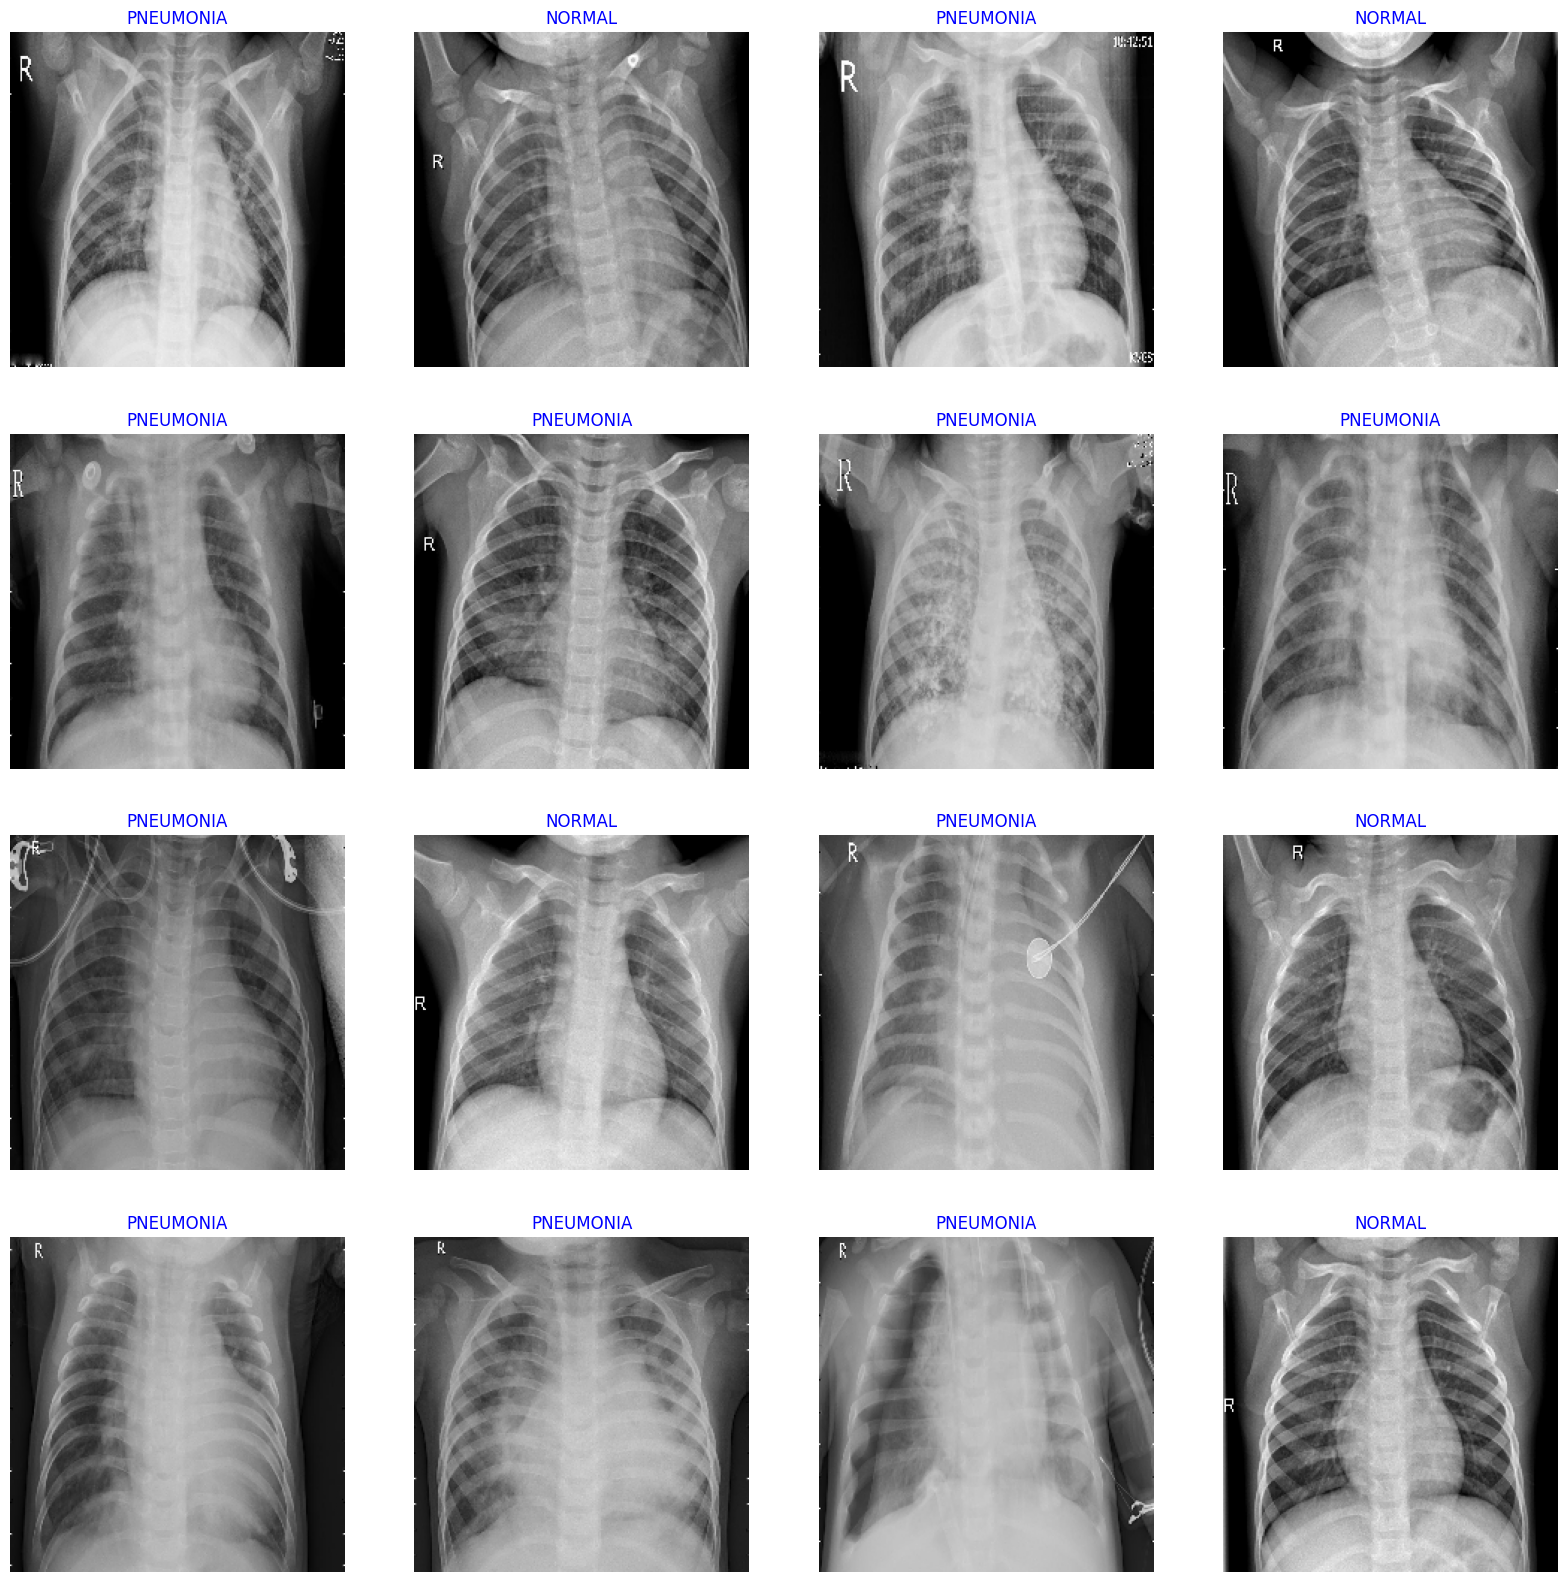

In [14]:
plt.figure(figsize= (20, 20))

for i in range(16):
    plt.subplot(4, 4, i + 1)
    image = images[i] / 255
    plt.imshow(image)
    index = np.argmax(labels[i])
    class_name = classes[index]
    plt.title(class_name, color= 'blue', fontsize= 12)
    plt.axis('off')
plt.show()

In [15]:
img_size = (224, 224)
channels = 3
img_shape = (img_size[0], img_size[1], channels)
class_count = len(list(train_gen.class_indices.keys()))

base_model = tf.keras.applications.efficientnet.EfficientNetB0(include_top= False, weights= "imagenet", input_shape= img_shape, pooling= 'max')

# Freeze the pretrained backbone so only the classification head trains.
# Without this, the entire ~4M-parameter EfficientNetB0 gets fine-tuned from
# epoch 1 at a fairly high learning rate, which is unstable on a dataset this
# size -- it can collapse into a degenerate solution where the network's
# features flatten out and it outputs close to a constant regardless of
# input. Freezing the backbone is the standard, stable way to do transfer
# learning on a dataset this size.
base_model.trainable = False

model = Sequential([
    base_model,
    BatchNormalization(axis= -1, momentum= 0.99, epsilon= 0.001),
    Dense(256, kernel_regularizer= regularizers.l2(0.016), activity_regularizer= regularizers.l1(0.006),
                bias_regularizer= regularizers.l1(0.006), activation= 'relu'),
    Dropout(rate= 0.45, seed= 123),
    Dense(class_count, activation= 'softmax')
])

model.compile(Adamax(learning_rate= 0.001), loss= 'categorical_crossentropy', metrics= ['accuracy'])

model.summary()


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 1280)           │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           514 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,383,141 (16.72 MB)

 Trainable params: 331,010 (1.26 MB)

 Non-trainable params: 4,052,131 (15.46 MB)

In [16]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.utils.class_weight import compute_class_weight

checkpoint_path = 'best_checkpoint.weights.h5'

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

# Saves the best-val-loss weights to disk DURING training, independent of
# whatever ends up in the `model` variable afterward. This is the single
# most important safeguard in this notebook -- it means there is always a
# known-good checkpoint on disk no matter what happens to `model` later
# (e.g. accidentally re-running the model-definition cell above).
checkpoint = ModelCheckpoint(
    checkpoint_path,
    monitor='val_loss',
    save_best_only=True,
    save_weights_only=True,
    verbose=1
)

# Handle the Normal/Pneumonia class imbalance explicitly, rather than hoping
# the model figures it out on its own.
class_weights_arr = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_gen.classes),
    y=train_gen.classes
)
class_weight = dict(enumerate(class_weights_arr))
print('Using class weights:', class_weight)

history = model.fit(
    train_gen,
    validation_data=valid_gen,
    epochs=20,
    callbacks=[early_stop, checkpoint],
    class_weight=class_weight,
    shuffle=True
)


Using class weights: {0: np.float64(1.9350649350649352), 1: np.float64(0.6742081447963801)}
Epoch 1/20
261/261 ━━━━━━━━━━━━━━━━━━━━ 0s 301ms/step - accuracy: 0.7773 - loss: 13.3131
Epoch 1: val_loss improved from None to 4.87069, saving model to best_checkpoint.weights.h5

Epoch 1: finished saving model to best_checkpoint.weights.h5
261/261 ━━━━━━━━━━━━━━━━━━━━ 141s 409ms/step - accuracy: 0.8253 - loss: 9.4197 - val_accuracy: 0.9137 - val_loss: 4.8707
Epoch 2/20
261/261 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step - accuracy: 0.8798 - loss: 4.3800
Epoch 2: val_loss improved from 4.87069 to 3.18513, saving model to best_checkpoint.weights.h5

Epoch 2: finished saving model to best_checkpoint.weights.h5
261/261 ━━━━━━━━━━━━━━━━━━━━ 51s 196ms/step - accuracy: 0.8809 - loss: 3.9366 - val_accuracy: 0.9345 - val_loss: 3.1851
Epoch 3/20
261/261 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step - accuracy: 0.8999 - loss: 2.8257
Epoch 3: val_loss improved from 3.18513 to 2.04620, saving model to best_checkpoint.weights

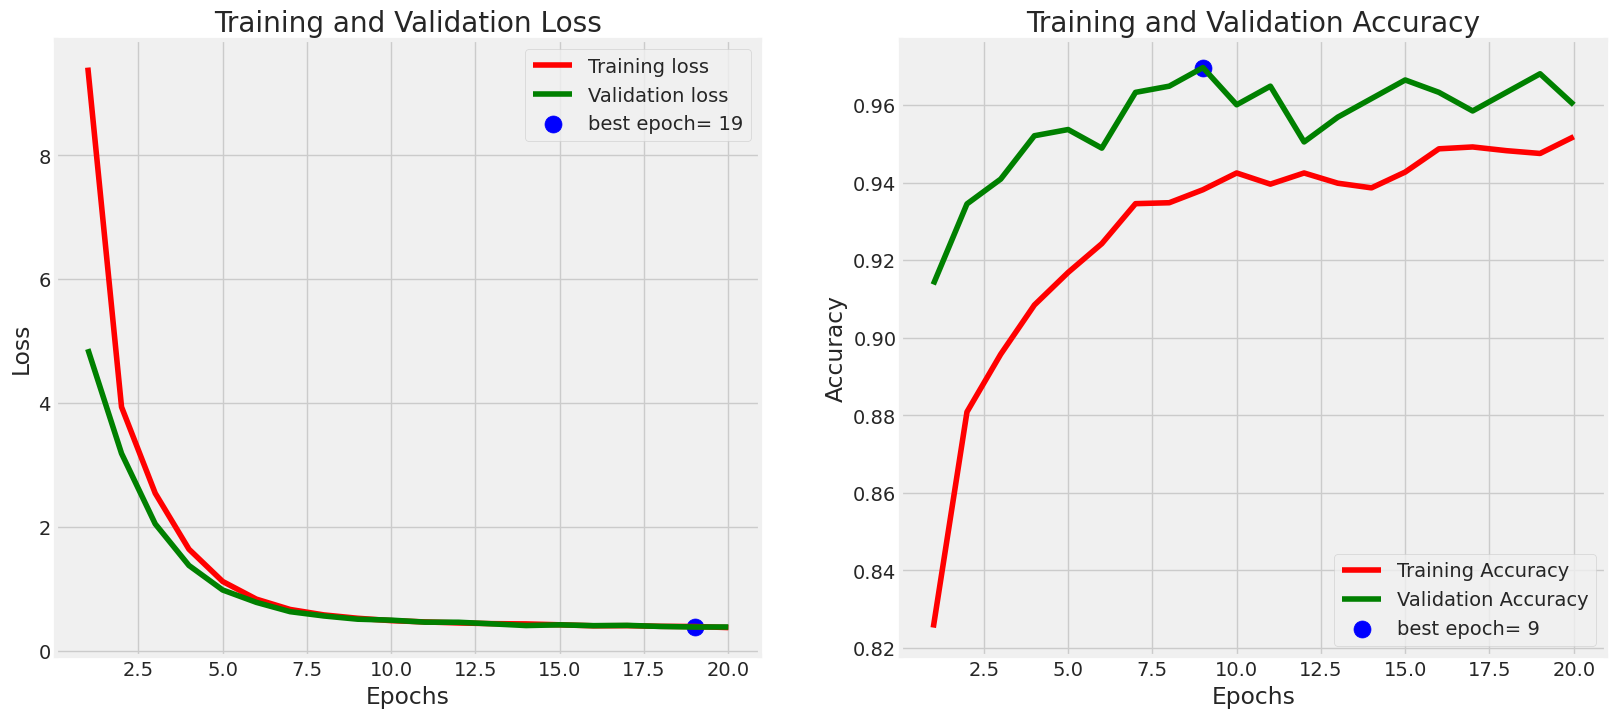

In [17]:
tr_acc = history.history['accuracy']
tr_loss = history.history['loss']
val_acc = history.history['val_accuracy']
val_loss = history.history['val_loss']
index_loss = np.argmin(val_loss)
val_lowest = val_loss[index_loss]
index_acc = np.argmax(val_acc)
acc_highest = val_acc[index_acc]
Epochs = [i+1 for i in range(len(tr_acc))]
loss_label = f'best epoch= {str(index_loss + 1)}'
acc_label = f'best epoch= {str(index_acc + 1)}'

plt.figure(figsize= (20, 8))
plt.style.use('fivethirtyeight')

plt.subplot(1, 2, 1)
plt.plot(Epochs, tr_loss, 'r', label= 'Training loss')
plt.plot(Epochs, val_loss, 'g', label= 'Validation loss')
plt.scatter(index_loss + 1, val_lowest, s= 150, c= 'blue', label= loss_label)
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(Epochs, tr_acc, 'r', label= 'Training Accuracy')
plt.plot(Epochs, val_acc, 'g', label= 'Validation Accuracy')
plt.scatter(index_acc + 1 , acc_highest, s= 150, c= 'blue', label= acc_label)
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout
plt.show()

In [18]:
# Reload the best frozen-backbone checkpoint first, then unfreeze for gentle fine-tuning.
model.load_weights(checkpoint_path)

base_model.trainable = True
model.compile(Adamax(learning_rate=1e-5), loss='categorical_crossentropy', metrics=['accuracy'])

finetune_checkpoint = ModelCheckpoint(
    checkpoint_path,  # overwrite the same checkpoint only if fine-tuning actually improves it
    monitor='val_loss',
    save_best_only=True,
    save_weights_only=True,
    verbose=1
)

finetune_history = model.fit(
    train_gen,
    validation_data=valid_gen,
    epochs=8,
    callbacks=[early_stop, finetune_checkpoint],
    class_weight=class_weight,
    shuffle=True
)

# Always reload the best checkpoint after -- if fine-tuning didn't help,
# this restores the good frozen-backbone weights rather than keeping a worse result.
model.load_weights(checkpoint_path)
print('Reloaded best checkpoint after fine-tuning.')


Epoch 1/8
261/261 ━━━━━━━━━━━━━━━━━━━━ 0s 342ms/step - accuracy: 0.7896 - loss: 0.7171
Epoch 1: val_loss improved from None to 0.79953, saving model to best_checkpoint.weights.h5

Epoch 1: finished saving model to best_checkpoint.weights.h5
261/261 ━━━━━━━━━━━━━━━━━━━━ 186s 419ms/step - accuracy: 0.8154 - loss: 0.6608 - val_accuracy: 0.7748 - val_loss: 0.7995
Epoch 2/8
261/261 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step - accuracy: 0.8469 - loss: 0.5972
Epoch 2: val_loss improved from 0.79953 to 0.57247, saving model to best_checkpoint.weights.h5

Epoch 2: finished saving model to best_checkpoint.weights.h5
261/261 ━━━━━━━━━━━━━━━━━━━━ 55s 209ms/step - accuracy: 0.8610 - loss: 0.5640 - val_accuracy: 0.8610 - val_loss: 0.5725
Epoch 3/8
261/261 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step - accuracy: 0.8749 - loss: 0.5292
Epoch 3: val_loss improved from 0.57247 to 0.42796, saving model to best_checkpoint.weights.h5

Epoch 3: finished saving model to best_checkpoint.weights.h5
261/261 ━━━━━━━━━━━━━━━━━━━━ 5

In [19]:
ts_length = len(test_df)
test_batch_size = max(sorted([ts_length // n for n in range(1, ts_length + 1) if ts_length%n == 0 and ts_length/n <= 80]))
test_steps = ts_length // test_batch_size

train_score = model.evaluate(train_gen, steps= test_steps, verbose= 1)
valid_score = model.evaluate(valid_gen, steps= test_steps, verbose= 1)
test_score = model.evaluate(test_gen, steps= test_steps, verbose= 1)

print("Train Loss: ", train_score[0])
print("Train Accuracy: ", train_score[1])
print('-' * 20)
print("Validation Loss: ", valid_score[0])
print("Validation Accuracy: ", valid_score[1])
print('-' * 20)
print("Test Loss: ", test_score[0])
print("Test Accuracy: ", test_score[1])

11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 263ms/step - accuracy: 0.9375 - loss: 0.3766
11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 274ms/step - accuracy: 0.8864 - loss: 0.4551
11/11 ━━━━━━━━━━━━━━━━━━━━ 18s 560ms/step - accuracy: 0.8971 - loss: 0.5359
Train Loss:  0.37659952044487
Train Accuracy:  0.9375
--------------------
Validation Loss:  0.45511960983276367
Validation Accuracy:  0.8863636255264282
--------------------
Test Loss:  0.5359318256378174
Test Accuracy:  0.8971291780471802


In [20]:
preds = model.predict(test_gen)
y_pred = np.argmax(preds, axis=1)

11/11 ━━━━━━━━━━━━━━━━━━━━ 11s 312ms/step


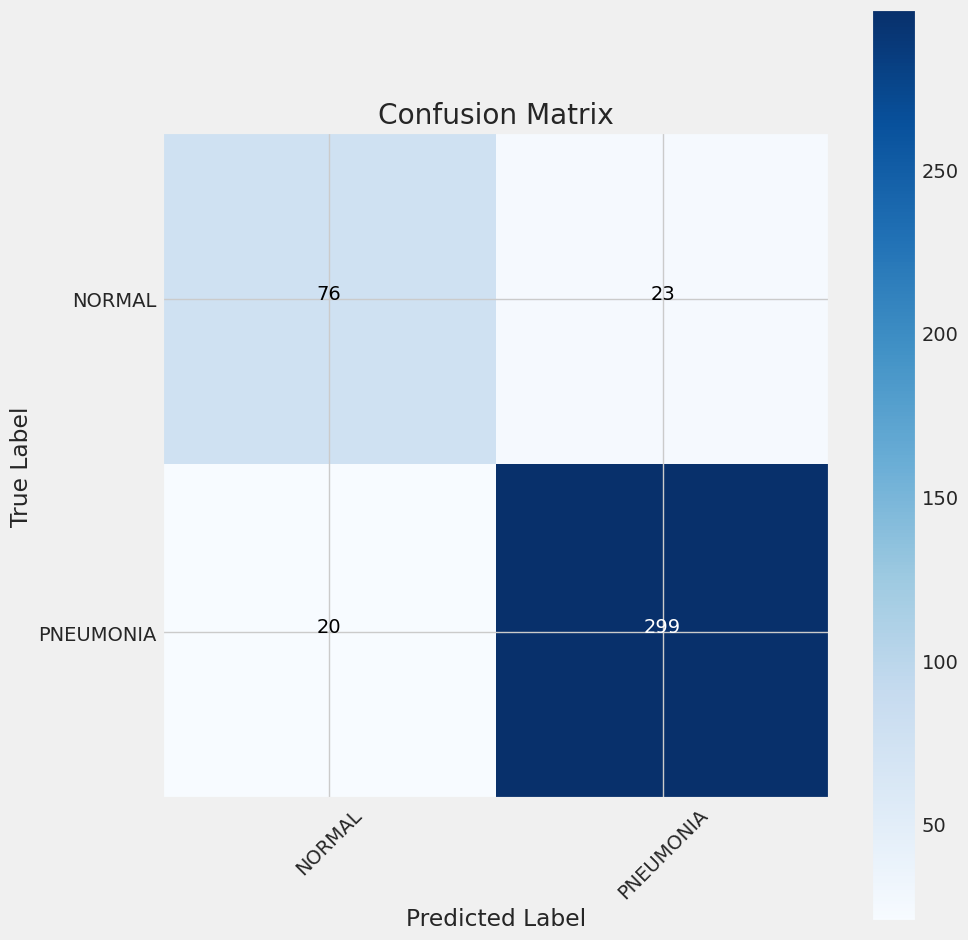

In [21]:
g_dict = test_gen.class_indices
classes = list(g_dict.keys())

# Confusion matrix
cm = confusion_matrix(test_gen.classes, y_pred)

plt.figure(figsize= (10, 10))
plt.imshow(cm, interpolation= 'nearest', cmap= plt.cm.Blues)
plt.title('Confusion Matrix')
plt.colorbar()

tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes, rotation= 45)
plt.yticks(tick_marks, classes)


thresh = cm.max() / 2.
for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(j, i, cm[i, j], horizontalalignment= 'center', color= 'white' if cm[i, j] > thresh else 'black')

plt.tight_layout()
plt.ylabel('True Label')
plt.xlabel('Predicted Label')

plt.show()

In [22]:
print(classification_report(test_gen.classes, y_pred, target_names= classes))

              precision    recall  f1-score   support

      NORMAL       0.79      0.77      0.78        99
   PNEUMONIA       0.93      0.94      0.93       319

    accuracy                           0.90       418
   macro avg       0.86      0.85      0.86       418
weighted avg       0.90      0.90      0.90       418



In [23]:
model_name = base_model.name
subject = 'pneumonia'
acc = test_score[1] * 100
save_path = ''

# Reload the verified-best checkpoint one more time immediately before saving,
# so this cell can never accidentally save a stale/reset `model`.
model.load_weights(checkpoint_path)

save_id = str(f'{model_name}-{subject}-{"%.2f" %round(acc, 2)}.h5')
model_save_loc = os.path.join(save_path, save_id)
model.save(model_save_loc)
print(f'model was saved as {model_save_loc}')

weight_save_id = str(f'{model_name}-{subject}.weights.h5')
weights_save_loc = os.path.join(save_path, weight_save_id)
model.save_weights(weights_save_loc)
print(f'weights were saved as {weights_save_loc}')


model was saved as efficientnetb0-pneumonia-89.71.h5
weights were saved as efficientnetb0-pneumonia.weights.h5


In [24]:
# --- Automated sanity check: catches a broken/collapsed export before you ---
# --- ever download the file.                                              ---
import numpy as np

def _predict(img_array):
    return model.predict(np.expand_dims(img_array, axis=0), verbose=0)[0]

black = np.zeros((224, 224, 3), dtype='float32')
white = np.full((224, 224, 3), 255, dtype='float32')
noise = np.random.randint(0, 255, (224, 224, 3)).astype('float32')

pred_black = _predict(black)
pred_white = _predict(white)
pred_noise = _predict(noise)

print('Solid black prediction:', pred_black)
print('Solid white prediction:', pred_white)
print('Random noise prediction:', pred_noise)
print('(Solid-color/noise inputs are heavily out-of-distribution for a model')
print(' trained only on real X-rays, so some oddity here is not conclusive')
print(' on its own -- the check below on real images is the one that matters.)')

# The REAL test: several actual X-rays with different true labels
real_batch_images, real_batch_labels = next(test_gen)
real_true_idx = np.argmax(real_batch_labels, axis=1)
real_preds = model.predict(real_batch_images, verbose=0)
class_names = list(test_gen.class_indices.keys())

print()
print('--- Real image check (this is the one that actually matters) ---')
for i in range(min(6, len(real_preds))):
    true_label = class_names[real_true_idx[i]]
    pred_label = class_names[np.argmax(real_preds[i])]
    correct = 'OK' if true_label == pred_label else 'WRONG'
    print(f'  [{correct}] true={true_label:10s} pred={pred_label:10s} probs={real_preds[i]}')

real_spread = np.max(np.abs(real_preds[0] - real_preds[1]))
n_correct = sum(class_names[real_true_idx[i]] == class_names[np.argmax(real_preds[i])] for i in range(len(real_preds)))

print()
if real_spread < 0.02:
    print(f'FAIL: even two real X-rays with different labels get near-identical predictions (spread={real_spread:.4f}).')
    print('   The model genuinely is not distinguishing real images. Do not use this export.')
elif n_correct < len(real_preds) * 0.5:
    print(f'WARN: predictions vary across images, but only {n_correct}/{len(real_preds)} match their true label.')
    print('   Something is still off -- worth investigating before using this export.')
else:
    print(f'PASS: real images get varied, mostly-correct predictions ({n_correct}/{len(real_preds)} correct, spread={real_spread:.4f}).')
    print('   This export looks healthy.')


Solid black prediction: [0.19680512 0.80319494]
Solid white prediction: [0.19680512 0.80319494]
Random noise prediction: [1. 0.]
(Solid-color/noise inputs are heavily out-of-distribution for a model
 trained only on real X-rays, so some oddity here is not conclusive
 on its own -- the check below on real images is the one that matters.)

--- Real image check (this is the one that actually matters) ---
  [OK] true=PNEUMONIA  pred=PNEUMONIA  probs=[0.19680512 0.80319494]
  [OK] true=PNEUMONIA  pred=PNEUMONIA  probs=[0.39277777 0.60722226]
  [OK] true=PNEUMONIA  pred=PNEUMONIA  probs=[0.19680512 0.80319494]
  [OK] true=PNEUMONIA  pred=PNEUMONIA  probs=[0.19680512 0.80319494]
  [OK] true=PNEUMONIA  pred=PNEUMONIA  probs=[0.19680512 0.80319494]
  [OK] true=NORMAL     pred=NORMAL     probs=[0.99706715 0.00293286]

PASS: real images get varied, mostly-correct predictions (34/38 correct, spread=0.1960).
   This export looks healthy.


In [25]:
class_dict = train_gen.class_indices
img_size = train_gen.image_shape
height = []
width = []
for _ in range(len(class_dict)):
    height.append(img_size[0])
    width.append(img_size[1])

Index_series = pd.Series(list(class_dict.values()), name= 'class_index')
Class_series = pd.Series(list(class_dict.keys()), name= 'class')
Height_series = pd.Series(height, name= 'height')
Width_series = pd.Series(width, name= 'width')
class_df = pd.concat([Index_series, Class_series, Height_series, Width_series], axis= 1)
csv_name = f'{subject}-class_dict.csv'
csv_save_loc = os.path.join(save_path, csv_name)
class_df.to_csv(csv_save_loc, index= False)
print(f'class csv file was saved as {csv_save_loc}')

class csv file was saved as pneumonia-class_dict.csv
